2025-04-29 13:06:13.188425: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6074
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2858
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2545
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2318
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2112
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1961
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1863
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1776
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1710
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1663
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1609
Epoch 12/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1574
Epoch 13/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1529
Epoch 14/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1490
Epoch 15/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1466
Epoch 16/20
40/40

/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


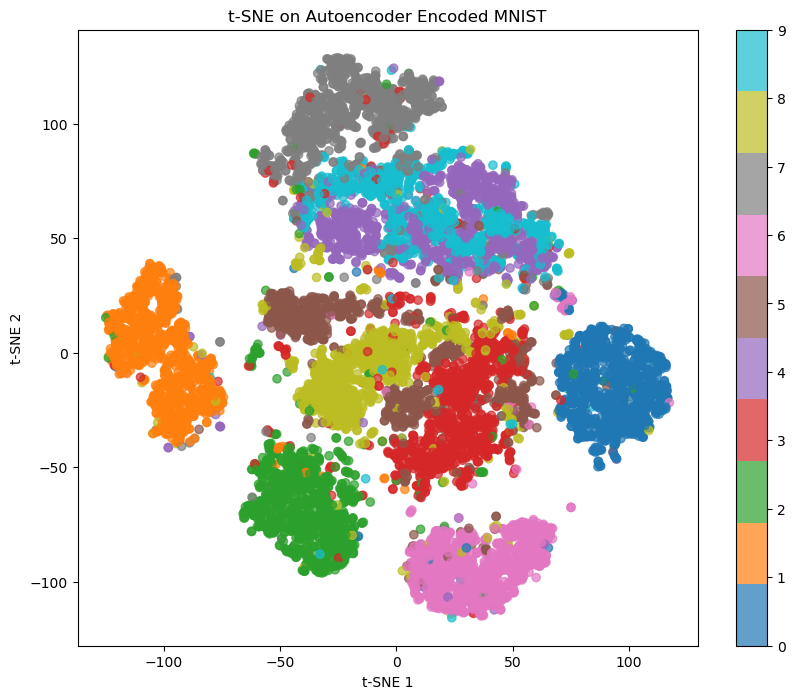

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tensorflow.python import keras
from tensorflow.python.keras import layers
from tensorflow.python.keras.datasets import mnist

# 1. Load MNIST
(x_train, y_train), (_, _) = mnist.load_data()

# Flatten and normalize
x_train_flat = x_train.reshape(-1, 784).astype('float32') / 255.0

# 2. Build Autoencoder
encoding_dim = 32

input_img = keras.Input(shape=(784,))
# Encoder part
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
# Decoder part
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# Models
autoencoder = keras.Model(input_img, decoded)
encoder = keras.Model(input_img, encoded)

# Create decoder separately
encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

# Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 3. Train Autoencoder
n_samples = 10000  # Use subset for speed
x_subset = x_train_flat[:n_samples]
y_subset = y_train[:n_samples]

autoencoder.fit(x_subset, x_subset,
                epochs=20,
                batch_size=256,
                shuffle=True,
                verbose=1)

# 4. Encode images
encoded_imgs = encoder.predict(x_subset)

# 5. Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=3000)
x_tsne = tsne.fit_transform(encoded_imgs)

# 6. Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(x_tsne[:, 0], x_tsne[:, 1], c=y_subset, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title('t-SNE on Autoencoder Encoded MNIST')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()
